# HW2 Coding Problems
## Linear Regression
---
Jinbo Adapted from AI4All at Princeton Univ.
This problem asks you to first implement your own linear regression algorithm. Then it allows you to use functions from Scikit-Learn to run linear regression as well as logistic regression, and compare.

### Problem 1

You decide to use linear regression to predict the battery life of the phone. The features you pick are $x_1$ = phone weight and $x_2$ = screen size.  The linear regression model with two features and two weights is given by:

> $\hat{y} = w_1x_1 + w_2x_2$

| Weight (ounces) | Screen Size (squared inches) | Battery Life (hours) |
|-|-|-|
| 6 | 4 | 12 |
| 13 | 16 | 24 |
| 5 | 15 | 20 |
| 9 | 48 | 21 |
| 7 | 13 | 16 |


> a. You initially guess $w_1=3$ and $w_2=4$. What is the predicted battery life for a phone of weight 10 ounces and screen size 18 squared inches?

102

> b. Recall the formula for Mean Squared Error (MSE) for this model is:

> > $f: \frac{1}{N}\sum_{i=1}^N (w_1x_1^i+w_2x_2^i-y^i)^2$

> What is the MSE for the model with $w_1=3$ and $w_2=4$?

In [ ]:
# Remember that you can use some code to perform these calculations if you like.
# Google Colab also has a scratch code cell in the Insert menu.
#phoneData is the DataFrame where the data for phone battery life is stored. Feel free to print it out to see what it looks like.
import pandas as pd
phoneData = pd.DataFrame([[6, 4, 12],[13, 16, 24], [5, 15, 20], [8, 48, 21], [7, 13, 16]], columns=['Weight', 'Screen Size', 'Battery Life'])

def mse(w1, w2):
    error = 0
    for index, row in phoneData.iterrows():
        # can acess weight of first row using row["Weight"], likewise for screen size and battery life
        ...
        # your code here
    return error / 5
mse(None, None)

mse(3, 4)

0.0

> c. Because a stochastic gradient based on a single example ($[x_1, x_2]$, $y$) would be $\nabla f =(2(w_1x_1+w_2x_2-y)x_1,  2(w_1x_1+w_2x_2-y)x_2)$. We can absorb the constant 2 into the step size $\alpha$. Thus the update functions for the weights are:

>> $w_1 = w_1 - \alpha * (w_1x_1+w_2x_2-y)* x_1$

>> $w_2 = w_2 - \alpha * (w_1x_1+w_2x_2-y)* x_2$

> Using the first data point as your example $([x_1,x_2], y)$ and setting $\alpha=0.05$, what are the new weights after one round of updates?

In [ ]:
w1, w2 = 3, 4
x1, x2 = 6, 4
y = 12
alpha = 0.05

# write the updates here
w1 = ... # replace with your code!
w2 = ... # replace with your code!

> d. What is the new MSE after one round of updates? Did the MSE increase or decrease after updating?

> e. Run the above stochastic gradient descent update for 20 iterations, and report the MSE value.  Note that at each iteration, you need to randomly sample an example from the battery life data, and use this sample to compute the stochastic gradient.

### Problem 2

Let's explore regression using scikit-learn. We'll use a [dataset on diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html), with 442 samples and 10 different features. We will focus on using a single feature, body mass index. The target values are a quantitative measure of diabetes progression one year after baseline.

> To start, we import the models, the dataset, and some extra tools.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
# Get the data samples and extract the feature at index 2,
# which is body mass index
X = diabetes.data[:, np.newaxis, 2]
y = diabetes.target

> Now we can split our dataset into training and test sets. The `train_test_split()` method can do this for us. Here we use an 80/20 split. Then we create the regression classifiers, train them on the training set, and evaluate the models on the test set, printing out the mean squared error.

In [ ]:
# Partition the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

# Instantiate the classifiers
lin_clf = LinearRegression()
# The parameters here are the default values for LogisticRegression,
# included here just to suppress a couple warnings
log_clf = LogisticRegression(solver='lbfgs', multi_class='multinomial')

# Train the classifiers
lin_clf.fit(X_train, y_train)
log_clf.fit(X_train, y_train)

# Calculate predictions on test set
lin_predictions = lin_clf.predict(X_test)
log_predictions = log_clf.predict(X_test)

> To get a better idea of what these models look like, let's plot the models' predictions on top of the test set.

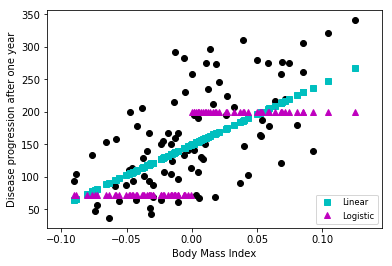

In [ ]:
import matplotlib.pyplot as plt

# Plot the dataset points
plt.scatter(X_test, y_test, color='black')

# Plot the linear regression predictions
# 'cs' means cyan is the color, square is the shape
plt.plot(X_test, lin_predictions, 'cs')

# Plot the logistic regression predictions
# 'm^' means magenta is the color, triangle is the shape
plt.plot(X_test, log_predictions, 'm^')

# Label axes and legend
plt.xlabel("Body Mass Index")
plt.ylabel("Disease progression after one year")
plt.legend(('Linear', 'Logistic'),
           loc="lower right", fontsize='small')
# Show the plot
plt.show()

> Recall the formula for the error function of our linear regression model, as an example: $w_1x+w_0-y$. We take the input, $x$, place it into our linear model, $w_1x+w_0$, and subtract the true value, $y$. A useful measure of how closely our model predicts all the test samples is Mean Squared Error (MSE). We simply square all of our error values, sum those squares, then divide by $N$ to calculate the mean squared error:

>> $\frac{1}{N}\sum_{i=1}^N (w_1x+w_0-y)^2$

> The logistic regression model has the same calculation for MSE, but with the sigmoid function as the model: $\frac{1}{1+e^{-(w_1x+w_0)}}$.

> Given the above plot, which regression model do you think has a larger mean squared error? Check your answer by writing code to report the MSE values for linear regression and logistic regression.